# Planetary Physics by Paul Andreini
Lol I'm bored so lemme make some planets go round a star.

In [1]:
## Importing relevant packages...
import os
import gc  ## Garbage Collection module: minimizes RAM overhead, especially when saving the jpegs.
import time as t
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg  ## Allows a figure to be saved without rendering first; see above comment.

print("Done!")

Done!


In [2]:
## Defining universal physical constants...
SOLAR_MASS   = 1.989e30   ## kg
ASTRO_UNIT   = 1.496e11   ## m
CAPITAL_G    = 6.674e-11  ## N kg^-2 m^2
DAY_IN_SEC   = 86400      ## s
JULIAN_YR    = 365.25 * DAY_IN_SEC     ## one Julian year in seconds.
N_JULIAN_YRS = 165  ## How many Julian years do we want to simulate? 1 == period of Earth; 165 == period of Neptune.
ORB_CIRCUM   = 2 * np.pi * ASTRO_UNIT  ## C = 2πr
ORB_VELOC    = ORB_CIRCUM / JULIAN_YR  ## v = ∆x/∆t

## Defining orbital parameters for use later.
DT = 60  ## number of seconds between each time-point.
STEPS = int((N_JULIAN_YRS * JULIAN_YR + 1) / DT)  ## INTEGER number of time-points ((N Julian yrs + 1 sec) / dt);
                                                  ##  number of evolution time-steps.
REVS = (STEPS * DT) / JULIAN_YR  ## number of revolutions to be simulated.

print(f"We will be simulating {np.round(REVS, 3)} complete orbits of Earth about the Sun.")

We will be simulating 165.0 complete orbits of Earth about the Sun.


In [3]:
def time_printer(st: t.time(), en: t.time(), op: str=None):
    """
       Prints elapsed time in a human-readable format: "#h hr; #m min; #s sec".
    
       ARGUMENTS:
        st (t.time() time point): FIRST point in time;
        en (t.time() time point): FINAL point in time;
        op (str): OPTIONAL description of the operation being performed/timed.
    
       RETURNS:
        VOID (prints out elapsed time in the above-indicated format)
    """    
    ## Correct mathematics.
    delta_t = en - st
    num_hr = int(delta_t / 3600)  ## Double-divide ("//") doesn't appear to be working, here...
    rem_hr = delta_t % 3600       ## Modulo operator; this is elapsed time less the whole number of hours.
    num_mn = int(rem_hr / 60)
    num_sc = np.round(rem_hr % 60, 4)
    
    ## Correct capitalization.
    if op is None:
        op = "Operation"
    else:
        op = op[:1].upper() + op[1:].lower()

    ## Correct grammar.
    hr = "hours"
    mn = "minutes"
    sc = "seconds"
    if num_hr == 1:
        hr = "hour"
    if num_mn == 1:
        mn = "minute"
    if num_sc == 1.0:
        sc = "second"

    ## Correct printout.
    print(f"{op} complete in {num_hr} {hr}; {num_mn} {mn}; {num_sc} {sc}.")
    
print("Done!")

Done!


## Online Hint
See, e.g., [https://math.stackexchange.com/questions/721076/help-with-using-the-runge-kutta-4th-order-method-on-a-system-of-2-first-order-od] for an application of RK4 to a 2nd-order ODE. Basically, you have to define $\boldsymbol{v} := \dot{\boldsymbol{x}}$ to convert the 2nd-order ODE into a system of two 1st-order ODE's.
__________________________________________________

## Problem Statement
In the two-body case (for just the Sun, $\odot$, and one planet, $p$), we have for the planetary acceleration (based on ***Newton's Law of Gravitation***):
\begin{align}
    \mathbf{F}_{\!p,\odot} = m_{p}\ddot{\mathbf{x}}_{p,\odot}
        &= -\frac{Gm_{\odot}m_{p}\mathbf{x}_{p,\odot}}{{x}_{p,\odot}^{3}}
    \tag{1}\\
    \implies\ddot{\mathbf{x}}_{p,\odot} &= -\frac{Gm_{\odot}\mathbf{x}_{p,\odot}}{{x}_{p,\odot}^{3}}\,,
    \tag{2}
\end{align}
where $\ddot{\mathbf{x}}_{p,\odot}$ is the acceleration of planet $p$ due to the Sun's gravity, $G = 6.674\times10^{-11}\,\text{m}^{3}\,\text{kg}^{-1}\,\text{s}^{-2}$ is **Newton's Gravitational Constant**, $m_{\odot} = 1.989\times10^{30}\,\text{kg}$ is the mass of the Sun, and $\mathbf{x}_{p,\odot}$ is the vector from the Sun to the planet (with $x_{p,\odot}$ as its length). Note that a dot over a quantity represents its time-derivative, and a double-dot over a quantity is its second time-derivative.

However, in this code, we numerically simulate the $N$-body problem for the entire Solar System ($N=9$, including the Sun and all eight planets). Thus, we must update the acceleration each planet experiences according not only to the gravitational attraction of the sun, but that of each of the other eight planets, too:
\begin{align}
    \mathbf{F}_{\!j,k} = m_{j}\ddot{\mathbf{x}}_{j,k} &= -\frac{Gm_{j}m_{k}\mathbf{x}_{j,k}}{x_{j,k}^{3}}
    \tag{3}\\
    \implies \ddot{\mathbf{x}}_{j,k} &= -\frac{Gm_{k}\mathbf{x}_{j,k}}{x_{j,k}^{3}}\,
    \tag{4}
\end{align}
where $\ddot{\mathbf{x}}_{j,k}$ is the acceleration of planet $j$ caused by the gravity of planet $k$, $m_{k}$ is the mass of planet $k$, and $\mathbf{x}_{j,k}$ is the distance between the two planets. Thus, the acceleration of planet $j$ due to all the other planets ***and*** the Sun is given by:
\begin{align}
    \implies \ddot{\mathbf{x}}_{j} &= \frac{1}{m_{j}}\big( \mathbf{F}_{\!j,\odot} + \Sigma_{k}\mathbf{F}_{\!j,k} \big)
    \tag{5}\\
    \implies \ddot{\mathbf{x}}_{j}
        &= -G\bigg( \frac{m_{\odot}\mathbf{x}_{j,\odot}}{x_{j,\odot}^{3}} 
            + \sum_{k=1}^{8}\big( 1-\delta_{j,k} \big)\frac{m_{k}\mathbf{x}_{j,k}}{x_{j,k}^{3}} \bigg)\,,
    \tag{6}\\
    \text{where }\delta_{j,k} &:= \begin{cases} 1\,, && j=k \\
        0\,, && j\neq k \end{cases}\,.
    \tag{7}
\end{align}
Note that we can reduce the second-order ordinary differential equation (ODE) in Eq. $6$ into a system two first-order ODEs by defining:
\begin{align}
    \dot{\mathbf{x}}_{j} &= \mathbf{v}_{\!j}\,;
    \tag{8}\\
    \dot{\mathbf{v}}_{\!j} &= -G\bigg( \frac{m_{\odot}\mathbf{x}_{j,\odot}}{x_{j,\odot}^{3}} 
        + \sum_{k=1}^{8}\big( 1-\delta_{j,k} \big)\frac{m_{k}\mathbf{x}_{j,k}}{x_{j,k}^{3}} \bigg)\,.
    \tag{9}
\end{align}
__________________________________________________

## *Generic* RK4 Algorithm for 2nd-order ODE's
#### *(Copied from above Math StackExchange link.)*
Suppose we want to solve the following (scalar-valued) 2nd-order ODE:
\begin{equation}
    y'' + y' - 6y = 0\,.
    \tag{i}
\end{equation}
Note that, in Eq. $\mathrm{i}$, it is implied that $y \equiv y(x)$, *i.e.*, $y$ is a univariate function of $x$. We can do so by splitting Eq. $\mathrm{i}$ into a system of two 1st-order ODE's, just as we did with Eq. $1$ to get Eqs. $3$ & $4$:
\begin{equation}
    \text{Let }z := y'\,.
    \tag{ii}
\end{equation}
Proceeding as above (*i.e.*, in the section called "**Problem Statement**"), we have for the system of 1st-order ODE's:
\begin{align}
    y' = z &=: f(x, y, z) \equiv f(z)\,;
    \tag{iii}\\
    z' = 6y - z &=: g(x, y, z) \equiv g(y, z)\,,
    \tag{iv}
\end{align}
Naturally, we need to supply initial conditions (analogous to Eqs. $5$ & $6$), and a time-step size, $h$:
\begin{align}
    y_{0} &= 3\,;
    \tag{v}\\
    z_{0} &= 1\,;
    \tag{vi}
\end{align}
### Here is the algorithm *in principle*.
Follow this order of execution ***precisely!*** Start with $n=0$.
\begin{align}
    k_{0} &= hf(x_{n}, y_{n}, z_{n})\,,
    \tag{vii}\\
    \ell_{0} &= hg(x_{n}, y_{n}, z_{n})\,;
    \tag{viii}\\
    k_{1} &= hf\Big( x_{n} + \frac{h}{2}, y_{n} + \frac{k_{0}}{2}, z_{n} + \frac{\ell_{0}}{2} \Big)\,,
    \tag{ix}\\
    \ell_{1} &= hg\Big( x_{n} + \frac{h}{2}, y_{n} + \frac{k_{0}}{2}, z_{n} + \frac{\ell_{0}}{2} \Big)\,;
    \tag{x}\\
    k_{2} &= hf\Big( x_{n} + \frac{h}{2}, y_{n} + \frac{k_{1}}{2}, z_{n} + \frac{\ell_{1}}{2} \Big)\,,
    \tag{xi}\\
    \ell_{2} &= hg\Big( x_{n} + \frac{h}{2}, y_{n} + \frac{k_{1}}{2}, z_{n} + \frac{\ell_{1}}{2} \Big)\,;
    \tag{xii}\\
    k_{3} &= hf(x_{n} + h, y_{n} + k_{2}, z_{n} + \ell_{2})\,,
    \tag{xiii}\\
    \ell_{3} &= hg(x_{n} + h, y_{n} + k_{2}, z_{n} + \ell_{2})\,.
    \tag{xiv}
\end{align}
Using the eight constants, $\{ k_{0}, \ell_{0}, k_{1}, \ell_{1}, k_{2}, \ell_{2}, k_{3}, \ell_{3} \}$, as well as the known variable values, $\{y_{n}, z_{n}\}$, we can calculate the updated variable values $\{y_{n+1}, z_{n+1}\}$:
\begin{align}
    y_{n+1} &= y_{n} + \frac{1}{6}\big( k_{0} + 2(k_{1} + k_{2}) + k_{3} \big)\,;
    \tag{xv}\\
    z_{n+1} &= z_{n} + \frac{1}{6}\big( \ell_{0} + 2(\ell_{1} + \ell_{2}) + \ell_{3} \big)\,.
    \tag{xvi}
\end{align}
We proceed with $n \to n+1$, and then repeat from Eq. $\mathrm{vii}$ once again. We repeat this loop-process until we have exhausted the desired steps in $x$.
### Here is the algorithm *in practice*.
Of course, in Eq. $\mathrm{iii}$, we determined that $f(x_{n}, y_{n}, z_{n}) \equiv f(z_{n}) = z_{n}$; likewise, in Eq. $\mathrm{iv}$, we determined that $g(x_{n}, y_{n}, z_{n}) \equiv g(y_{n}, z_{n}) = 6y_{n} - z_{n}$. Thus, our notation in Eqs. $\mathrm{vii}$ --- $\mathrm{xiv}$ was ***overly-generic***. Here, we evaluate the first step in the RK4 algorithm with our scalar-valued example (suppose we choose $h=0.1$):
\begin{align}
    k_{0} &= hz_{0} = 0.1(1) = 0.1\,,
    \tag{xvii}\\
    \ell_{0} &= h(6y_{0} - z_{0}) = 0.1\big( 6(3) - 1 \big) = 1.7\,;
    \tag{xviii}\\
    k_{1} &= h\Big( z_{0} + \frac{\ell_{0}}{2} \Big) = 0.1(1 + 0.85) = 0.185\,,
    \tag{xix}\\
    \ell_{1} &= h\Big\{ 6\Big( y_{0} + \frac{k_{0}}{2} \Big) - \Big( z_{0} + \frac{\ell_{0}}{2} \Big) \Big\}
        = 0.1\big\{ 6(3 + 0.85) - (1 + 0.0925) \big\}
        = 2.20075
    \tag{xx}
\end{align}
and so on and so forth. If we continue this process, say, out to $y_{10}$, we will find that it is extremely close to the exact solution, which is given by:
\begin{align}
    y(x) &= \exp{(-3x)} + 2\exp{(2x)}
    \tag{xxi}\\
    \implies y(1) &\approx 14.82789927
    \tag{xxii}
\end{align}
__________________________________________________

## *Specific* RK4 Algorithm for Newton's Law of Gravitation
Using Eq. $3$, in analogy to Eq. $\mathrm{iii}$, we have:
\begin{equation}
    \dot{\mathbf{x}}_{j} =: f\big( t, \mathbf{x}_{j}(t), \mathbf{v}_{\!j}(t) \big) \equiv f( \mathbf{v}_{\!j} )
        = \mathbf{v}_{\!j}\,;
    \tag{10}
\end{equation}
similarly, using Eq. $4$, in analogy to Eq. $\mathrm{iv}$, we have:
\begin{equation}
    \dot{\mathbf{v}}_{\!j} =: g\big( t, \mathbf{x}_{j}(t), \mathbf{v}_{\!j}(t) \big) \equiv g( \mathbf{x}_{j} )
        = -G\bigg( \frac{m_{\odot}\mathbf{x}_{j,\odot}}{x_{j,\odot}^{3}} 
            + \sum_{k=1}^{8}\big( 1-\delta_{j,k} \big)\frac{m_{k}\mathbf{x}_{j,k}}{x_{j,k}^{3}} \bigg)\,,
    \tag{11}
\end{equation}
We now proceed to apply the example algorithm to this specific case (dropping the subscript $j$, which refers to the planet; the subscript $n$ refers to the time-step).
\begin{align}
    \boldsymbol{k}_{0} &= hf\big( t_{n}, \mathbf{x}_{n}, \mathbf{v}_{\!n} \big) \equiv hf( \mathbf{v}_{\!n} )
        = h\mathbf{v}_{\!n}\,,
    \tag{12}\\
    \boldsymbol{\ell}_{0} &= hg\big( t_{n}, \mathbf{x}_{n}, \mathbf{v}_{\!n} \big) \equiv hg( \mathbf{x}_{n} )
        = -G\bigg( \frac{m_{\odot}\mathbf{x}_{j,\odot}}{x_{j,\odot}^{3}} 
            + \sum_{k=1}^{8}\big( 1-\delta_{j,k} \big)\frac{m_{k}\mathbf{x}_{j,k}}{x_{j,k}^{3}} \bigg)\,;
    \tag{13}\\
    \boldsymbol{k}_{1} &= hf\Big( \mathbf{v}_{\!n} + \frac{\boldsymbol{\ell}_{0}}{2} \Big)\,,
    \tag{14}\\
    \boldsymbol{\ell}_{1} &= hg\Big( \mathbf{x}_{n} + \frac{\boldsymbol{k}_{0}}{2} \Big)\,;
    \tag{15}\\
    \boldsymbol{k}_{2} &= hf\Big( \mathbf{v}_{\!n} + \frac{\boldsymbol{\ell}_{1}}{2} \Big)\,,
    \tag{16}\\
    \boldsymbol{\ell}_{2} &= hg\Big( \mathbf{x}_{n} + \frac{\boldsymbol{k}_{1}}{2} \Big)\,;
    \tag{17}\\
    \boldsymbol{k}_{3} &= hf(\mathbf{v}_{\!n} + \boldsymbol{\ell}_{2})\,,
    \tag{18}\\
    \boldsymbol{\ell}_{3} &= hg(\mathbf{x}_{n} + \boldsymbol{k}_{2})\,.
    \tag{19}
\end{align}
Using the eight constants, $\{ \boldsymbol{k}_{0}, \boldsymbol{\ell}_{0}, \boldsymbol{k}_{1}, \boldsymbol{\ell}_{1}, \boldsymbol{k}_{2}, \boldsymbol{\ell}_{2}, \boldsymbol{k}_{3}, \boldsymbol{\ell}_{3} \}$, as well as the known variable values, $\{\mathbf{x}_{n}, \mathbf{v}_{\!n}\}$, we can thus calculate the updated variable values $\{\mathbf{x}_{n+1}, \mathbf{v}_{\!n+1}\}$:
\begin{align}
    \mathbf{x}_{n+1} &= \mathbf{x}_{n} + \frac{1}{6}\big( \boldsymbol{k}_{0} + 2(\boldsymbol{k}_{1} + \boldsymbol{k}_{2}) + \boldsymbol{k}_{3} \big)\,;
    \tag{20}\\
    \mathbf{v}_{\!n+1} &= \mathbf{v}_{\!n} + \frac{1}{6}\big( \boldsymbol{\ell}_{0} + 2(\boldsymbol{\ell}_{1} + \boldsymbol{\ell}_{2}) + \boldsymbol{\ell}_{3} \big)\,.
    \tag{21}
\end{align}
Just as in our toy-model example, we proceed with $n \to n+1$ and we go back to Eq. $9$.

In [5]:
## Defining more constants, pertinent in particular to our Solar System.
##  Creating a dictionary: key is the English name of the planet; value is vector of mass [kg], semi-major axis [m], ...
##  ... and average orbital velocity [m s^-1].
PLANET_NAMES = np.array(["Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn", "Uranus", "Neptune"])
PLANET_MASSES = np.array([3.302e23, 4.867e24, 5.972e24, 6.417e23, 1.898e27, 5.683e26, 8.861e25, 1.024e26])    ## Unit: kg
SEMI_MAJOR_AXES = np.array([5.791e10, 1.082e11, 1.496e11, 2.279e11, 7.785e11, 1.433e12, 2.872e12, 4.495e12])  ## Unit: m
AVG_ORBITAL_VELOC = np.array([4.787e4, 3.502e4, 2.978e4, 2.407e4, 1.307e4, 9.690e3, 6.800e3, 5.430e3])        ## Unit: m s^-1

PLANETS = {
    name: np.array([mass, sma, veloc])
    for name, mass, sma, veloc in zip(
        PLANET_NAMES, PLANET_MASSES, SEMI_MAJOR_AXES, AVG_ORBITAL_VELOC
    )
}

print(PLANETS)

{'Mercury': array([3.302e+23, 5.791e+10, 4.787e+04]), 'Venus': array([4.867e+24, 1.082e+11, 3.502e+04]), 'Earth': array([5.972e+24, 1.496e+11, 2.978e+04]), 'Mars': array([6.417e+23, 2.279e+11, 2.407e+04]), 'Jupiter': array([1.898e+27, 7.785e+11, 1.307e+04]), 'Saturn': array([5.683e+26, 1.433e+12, 9.690e+03]), 'Uranus': array([8.861e+25, 2.872e+12, 6.800e+03]), 'Neptune': array([1.024e+26, 4.495e+12, 5.430e+03])}


In [6]:
class SolarSystem:

    """
       Radial-scaling transformations for plotting.
        The inner Solar System (Sun --> Mars) is quite compact compared to its full extent (Sun --> Neptune); thus, a "linear" radial ...
            ... scale would look like a bunch around the origin, with almost nothing but emptiness toward the radial extremity.
        Each option will map a radius (measured in AU) to a "de-bunched radius" while preserving polar angle with respect to +x-hat.
        All of these map r=0 --> r'=0, so that the Sun stays fixed at the origin regardless of radial scaling option chosen.
        To add a new scaling-option, simply add a new line to each of the two dictionaries, below!
    """
    _RADIAL_SCALING_OPTIONS = {
        "linear": lambda r_au: r_au,
        "sqrt": lambda r_au: np.sqrt(r_au),
        "log": lambda r_au: np.log10(1+r_au)  ## 1+ in the argument maps r=0 --> r'=0, so that the sun stays at the origin.
    }
    _SCALING_LABELS = {
        "linear": "Distance [AU]",
        "sqrt": r"Distance [$\sqrt{\mathrm{AU}}$]",
        "log": r"Distance [$\log_{10}{(1+\mathrm{AU})}$]"
    }

    ## With "figsize=(8, 8)", such as we use here, this will give 2160x2160px, which is 4K native height.
    RESOLUTION = 270
    
    
    def __init__(self):
        ## Loading in solar system properties.
        ##  Starting with the sun; this code works in the reference frame of the Sun, so semi-major axis and avg. orb. veloc. are both 0.
        self.solar_mass = SOLAR_MASS
        
        ##  Now, unpacking the dictionary into two different np.ndarray objects.
        self.planet_names = np.array(list(PLANETS.keys()))     ## shape (8, )
        self.planet_params = np.array(list(PLANETS.values()))  ## shape (8, 3).
        self.planet_params.flags.writeable = False  ## Enforcing the read-only nature of this array.
        
        ## Further unpacking the array of params into three vectors with more-descriptive names.
        MASS, SMA, VELOC = 0, 1, 2
        self.planet_masses = self.planet_params[:, MASS]
        self.planet_semi_major_axes = self.planet_params[:, SMA]
        self.planet_avg_orb_velocs = self.planet_params[:, VELOC]

        ## Randomizing the initial polar angles of the planets with respect to +x-hat.
        self.randomize_initial_polar_angles()
        self.earth_initial_radial_angle = 0.0
        self.earth_radial_angle = 0.0

        ## Assigning each planet a fixed, distinct color so its marker and orbit always match.
        self.planet_colors = list(plt.cm.tab10.colors)[:self.planet_names.size]

    
    def randomize_initial_polar_angles(self, seed=None):  ## Setting "seed=None" creates a random seed from entropy.
        """
           Assigns each planet a random polar angle on the semi-open set [0, 2*pi) at orbital radius r = a.

           This approximates each orbit as a circle of radius equal to the semi-major axis.
            The approximation is excellent for a snapshot: even Mercury (the most eccentric, with e = 0.206) has
                b/a = sqrt(1 - e^2) ~ 0.979, so the circular placement is within ~2% of the true ellipse and visually indistinguishable.
            Even were it not "visually indistinguishable," all this does is set the axis of the ellipse to be integrated.

           ARGUMENTS:
            seed (int or None): Optional RNG seed for reproducible configurations (useful when debugging).

           RETURNS:
            VOID (sets self.planetary_angles and self.planetary_positions)
        """
        rng = np.random.default_rng(seed)
        self.planetary_polar_angles = rng.uniform(0.0, 2.0*np.pi, size=self.planet_names.size)  ## Size: (8, )
        self.planetary_positions = self.planet_semi_major_axes * np.array([np.cos(self.planetary_polar_angles),
                                                                           np.sin(self.planetary_polar_angles)])

    
    def _scale_radial_positions(self, positions, scale_type):
        """
           Applies a radial transformation to N separate positions, preserving polar angle.
            The radius is first normalized to astronomical units; the origin maps to itself, 
                so the Sun remains centered (at the origin) under every scaling.

           ARGUMENTS:
            positions  (np.ndarray, dims=(2, K)): 2D positions of K points in the orbital plane.
                                                   K = Np when scaling instantaneous planet positions;
                                                   K = N  when scaling a recorded orbital trail.
            scale_type (str): Denotes whether to scale radii in a linear-, sqrt-, or log-fashion.

           RETURNS:
            r_new*unit (np.ndarray, dims=(2, K)): radially rescaled positions, polar angle preserved.
        """
        r = np.hypot(positions[0], positions[1])
        r_new = self._RADIAL_SCALING_OPTIONS[scale_type](r / ASTRO_UNIT)
        with np.errstate(divide="ignore", invalid="ignore"):
            unit = np.where(r > 0.0, positions / r, 0.0)  ## direction only (dimensionless)

        return r_new * unit

    
    def plot(self, scale_type="linear",
             x_vecs=None, v_vecs=None, a_vecs=None, paths=None,
             elapsed_jy=None,
             show=True, save=False, fname=None):
        """
           Plots the solar system. Optionally plots the instantaneous acceleration and velocity of the planet(s).
        
           ARGUMENTS:
            scale_type  (str): Indicates how to scale radial distance: linear, sqrt, or log.
            x_vecs      (np.ndarray, dims=(2, Np)): 2D POSITION vector for the planet (OPTIONAL here, but MANDATORY in save_jpegs(...)).
            v_vecs      (np.ndarray, dims=(2, Np)): 2D VELOCITY vector for the planet (OPTIONAL).
            a_vecs      (np.ndarray, dims=(2, Np)): 2D ACCELERATION vector for the planet (OPTIONAL).
            paths       (np.ndarray, dims=(Np, 2, N)): Matrix of "x_vec" values; traces out the orbit of the planet (OPTIONAL).
            elapsed_jy  (float or None): Elapsed time in Julian years; displayed in a box at the bottom-left if provided (OPTIONAL).
            show        (bool): Should the computer display the frame or not? Defaults to "True".
            save        (bool): Should the computer save the frame or not? Defaults to "False".
            fname       (str): If "save == True", then under what filename should the computer save the frame?
        
           RETURNS:
            VOID (shows a plot, with option to save the file locally)
        """
        ## First, validating the string passed as "scale_type"; including a potentially-helpful message.
        if scale_type not in self._RADIAL_SCALING_OPTIONS:
            valid = ", ".join(repr(j) for j in self._SCALING_LABELS)
            raise ValueError(f"Unknown scale {scale_type!r}. Valid options are: {valid}.")

        ## Transforming the radial planet positions into the desired scaling.
        if x_vecs is None:
            x_vecs = self.planetary_positions
        xs, ys = self._scale_radial_positions(x_vecs, scale_type)

        ## Regardless of our scaling option, dynamically set the appropriate size for the frame.
        r_max = np.hypot(xs, ys).max()
        if paths is not None:
            for path in paths:
                sx, sy = self._scale_radial_positions(path, scale_type)
                r_max = max(r_max, np.hypot(sx, sy).max())
        frame = 1.275 * r_max

        ## Setting up the figure object.
        if show:  ## case "show" the plot.
            plt.close()
            fig, ax = plt.subplots(figsize=(8, 8), dpi=self.RESOLUTION)
        else:  ## case "save" the plot.
            fig = Figure(figsize=(8, 8), dpi=self.RESOLUTION)
            FigureCanvasAgg(fig)
            ax = fig.add_subplot(111)
        ax.set_xlim(-frame, frame)
        ax.set_ylim(-frame, frame)
        ax.set_title("The Solar System", fontsize=18)
        ax.set_xlabel(self._SCALING_LABELS[scale_type], fontsize=15)
        ax.set_ylabel(self._SCALING_LABELS[scale_type], fontsize=15)
        ax.grid(True)

        ## Trajectories must be scaled with the same transform to stay consistent. Plotting each in its own color, for clarity.
        if paths is not None:
            for path, name, color in zip(paths, self.planet_names, self.planet_colors):
                sx, sy = self._scale_radial_positions(path, scale_type)
                ax.plot(sx, sy, c=color, lw=2, linestyle="--", label=f"{name} orbit")

        ## OPTIONAL: plotting instantaneous velocity/acceleration directions at the location of each planet.
        ##  NORMALIZING the vectors to show DIRECTION; including magnitude, too, introduces a distracting amount of clutter to the view.
        if v_vecs is not None:
            v_mags = np.hypot(v_vecs[0], v_vecs[1])          ## (Np, )
            v_unit = v_vecs / np.where(v_mags>0, v_mags, 1)  ## (2, Np)
            ax.quiver(xs, ys, v_unit[0], v_unit[1], color="royalblue",   label="Velocity",     alpha=0.25)
        if a_vecs is not None:
            a_mags = np.hypot(a_vecs[0], a_vecs[1])          ## (Np, )
            a_unit = a_vecs / np.where(a_mags>0, a_mags, 1)  ## (2, Np)
            ax.quiver(xs, ys, a_unit[0], a_unit[1], color="forestgreen", label="Acceleration", alpha=0.25)

        ## Plotting the Sun and each planet (in separate colors, for clarity).
        ax.scatter(0, 0, marker="*", s=400, c="goldenrod", edgecolor="k", label="Sun", zorder=3)  ## zorder determines what gets...
        ax.scatter(xs, ys, marker="o", s=60, c=self.planet_colors, edgecolor="k", zorder=3)       ##  plotted on top of what.

        ## Labeling each planet next to the marker on the graph.
        for name, x, y in zip(self.planet_names, xs, ys):
            ax.annotate(name, (x, y), textcoords="offset points", xytext=(6, 6), fontsize=8)

        ## OPTIONAL: elapsed-time display in the bottom-left corner.
        ##  transform=ax.transAxes means (x, y) are axis fractions (0–1), independent of data units or radial scaling.
        ##  zorder=5 places the box above the grid lines; facecolor="white" with alpha=1.0 makes it fully opaque,
        ##  so the grid cross-hatch is completely hidden behind the box.
        if elapsed_jy is not None:
            ax.text(
                0.02, 0.02,
                f"t = {elapsed_jy:.3f} Jy",
                transform  = ax.transAxes,
                fontsize   = 11,
                va         = "bottom",
                ha         = "left",
                zorder     = 5,
                bbox       = dict(
                    boxstyle  = "round,pad=0.4",
                    facecolor = "white",
                    edgecolor = "black",
                    alpha     = 1.0
                )
            )

        if save:
            if fname is None:
                fname_emessage_line1 = "Attempting to save a figure; no filename was provided.\n"
                fname_emessage_line2 = "Please supply a valid filename literal under the parameter 'fname'."
                fname_emessage = fname_emessage_line1 + fname_emessage_line2
                raise ValueError(fname_emessage)
            else:
                fig.savefig(f"{fname}.jpg", format="jpg", dpi=self.RESOLUTION)

        if show:
            plt.show()
        else:
            fig.clf()
            del fig


    def initial_state(self):
        """
           Builds the initial phase-space state consistent with the plotted geometry.
            Positions come straight from the randomized circular placement; velocities
            are tangential (perpendicular to the radius, counter-clockwise) with
            magnitudes equal to each planet's average orbital speed.

           RETURNS:
            x0 (np.ndarray, dims=(2, Np)): initial positions;
            v0 (np.ndarray, dims=(2, Np)): initial velocities.
        """
        x0 = self.planetary_positions.copy()                       ## (2, Np)
        theta = self.planetary_polar_angles                        ## (Np,)
        tangential = np.array([-np.sin(theta), np.cos(theta)])     ## (2, Np), CCW
        v0 = self.planet_avg_orb_velocs * tangential               ## broadcast (Np,) over rows
        return x0, v0


    @staticmethod  ## Means that this method can be called just like a static function: independently of the class.
    def _eff(v):
        """
           Evaluates function "f", defined in Eq. 7; this gives the VELOCITY vector for each planet.
        """
        return v


    def _gee(self, x, planet_planet=True):
        """
           Evaluates function "g", defined in Eq. 8; this gives the gravitational ACCELERATION vector on every planet at once
            (in the heliocentric reference frame).
    
           ARGUMENTS:
            x             (np.ndarray, dims=(2, Np)): planet positions, Sun fixed at the origin.
            planet_planet (bool): include mutual planet-planet forces (set False to recover the pure 2-body-per-planet behavior).
    
           RETURNS:
            a (np.ndarray, dims=(2, Np)): acceleration of each planet.
        """
        x = np.asarray(x, dtype=float)
    
        ## "Direct Sun term": ALWAYS include this.
        r = np.hypot(x[0], x[1])
        r_cubed = r ** 3
        """
           IMPORTANT SUBTLETY! The Sun accelerates due to the gravities of the planets.
            This is why the mass is the SUM of SOLAR MASS + ALL PLANETS' MASSES, not just the solar mass.
            THIS IS ESSENTIAL for our formulation--in the reference frame of the Sun, whereby the Sun stays fixed at the origin.
        """
        a = -CAPITAL_G * (self.solar_mass + PLANET_MASSES) * x / r_cubed
    
        if not planet_planet:
            return a
    
        ## Pair-wise planetary separations.
        dx = x[:, None, :] - x[:, :, None]  ## dx[:, i, j] = r_i - r_j; all vectors.
        d = np.hypot(dx[0], dx[1])
        np.fill_diagonal(d, np.inf)   ## Kill terms like j==k by setting their separation distance to infinity; no grav. accel.
        inv_d_cubed = 1.0 / (d ** 3)  ## 1/inf --> 0.

        ## sum_j G*m_j(r_j-r_i)/|r_j-r_i|^3
        ##  np.einsum evaluates a sum using the EINSTEIN SUMMATION CONVENTION.
        ##  https://en.wikipedia.org/wiki/Einstein_notation
        direct = CAPITAL_G * np.einsum('j,ij,kij->ki', PLANET_MASSES, inv_d_cubed, dx)

        ## Solar recoil: -G sum_j m_j r_j / |r_j|^3
        indirect = -CAPITAL_G * (PLANET_MASSES * (x / r_cubed)).sum(axis=1)[:, None]

        return a + direct + indirect


    ## Runge-Kutta 4th-order integrator method
    def _rk4_step(self, h, x_n, v_n):
        """
           Single RK4 step for Newton's Law of Gravitation over the whole system.
            Takes the time-step h and the current phase-space point {x_n, v_n},
            forms the intermediary vectors {k_j, l_j}, j = {0, 1, 2, 3}, and
            advances to {x_{n+1}, v_{n+1}}.

           ARGUMENTS:
            h (float): time-step size;
            x_n (np.ndarray, dims=(2, Np)): current positions;
            v_n (np.ndarray, dims=(2, Np)): current velocities.

           RETURNS:
            x_{n+1} (np.ndarray, dims=(2, Np)): next positions;
            v_{n+1} (np.ndarray, dims=(2, Np)): next velocities;
            a_{n+1} (np.ndarray, dims=(2, Np)): acceleration at the next positions.
        """
        ## 1st step: defining k0 and l0 vectors.
        k0 = h * self._eff(v_n)
        l0 = h * self._gee(x_n)

        ## 2nd step: defining k1 and l1 vectors.
        k1 = h * self._eff(v_n + (l0 / 2))
        l1 = h * self._gee(x_n + (k0 / 2))

        ## 3rd step: defining k2 and l2 vectors.
        k2 = h * self._eff(v_n + (l1 / 2))
        l2 = h * self._gee(x_n + (k1 / 2))

        ## 4th step: defining k3 and l3 vectors.
        k3 = h * self._eff(v_n + l2)
        l3 = h * self._gee(x_n + k2)

        ## 5th step: updating position and velocity vectors.
        x_nPlus1 = x_n + ((k0 + 2*(k1 + k2) + k3) / 6)
        v_nPlus1 = v_n + ((l0 + 2*(l1 + l2) + l3) / 6)

        return x_nPlus1, v_nPlus1, self._gee(x_nPlus1)


    @staticmethod  ## Means that this method can be called just like a static function: independently of the class.
    def _get_tenths(total):
        """
           Returns the step-indices at which to print 10%, 20%, ..., 80%, 90% progress.
        """
        return np.linspace(0, total - 1, 11).astype(int)[1:10]


    def integrate(self, h, N, x0=None, v0=None, verbose=True):
        """
           Runs the RK4 integrator to evolve the full N-body system.
            If x0/v0 are omitted, the system's own initial_state() is used.

           ARGUMENTS:
            h (float): time-step size;
            N (int): desired number of time-steps to evolve;
            x0 (np.ndarray, dims=(2, Np) or None): initial positions (defaults to initial_state());
            v0 (np.ndarray, dims=(2, Np) or None): initial velocities (defaults to initial_state());
            verbose (bool): print progress updates.

           RETURNS:
            x_hist (np.ndarray, dims=((N+1), 2, Np)): time series of positions;
            v_hist (np.ndarray, dims=((N+1), 2, Np)): time series of velocities;
            a_hist (np.ndarray, dims=((N+1), 2, Np)): time series of accelerations.
        """
        if x0 is None or v0 is None:
            x0, v0 = self.initial_state()

        x_list = [x0]
        v_list = [v0]
        a_list = [self._gee(x0)]
        counter = 0
        tenths = self._get_tenths(N)

        while counter < N:
            x1, v1, a1 = self._rk4_step(h=h, x_n=x0, v_n=v0)
            x_list.append(x1)
            v_list.append(v1)
            a_list.append(a1)
            x0 = x1
            v0 = v1

            if verbose:
                if counter == 0:
                    print("Algorithm has just begun!\n")
                elif counter in tenths:
                    idx = np.where(tenths == counter)[0][0]
                    pct = 10 * (idx + 1)
                    print(f"Algorithm has run {pct}% to completion!")

            counter += 1

        if verbose:
            print()  ## Blank line for clarity...

        return np.array(x_list), np.array(v_list), np.array(a_list)


    def save_jpegs(self, num_frames,
                   x_coords_list, v_coords_list, a_coords_list,
                   scale_type="linear", dest_dir="jpegs", verbose=True):
        """
           Saves JPEG frames capturing the evolution of the solar system through time.
            Frames are sampled uniformly in time from the integration history and saved
            to a local directory for later assembly into a video.

           ARGUMENTS:
            num_frames    (int): Desired number of output frames.
            x_coords_list (np.ndarray, dims=((N+1), 2, Np)): Time series of planetary POSITIONS, as returned by integrate();
            v_coords_list (np.ndarray, dims=((N+1), 2, Np)): Time series of planetary VELOCITIES, as returned by integrate();
            a_coords_list (np.ndarray, dims=((N+1), 2, Np)): Time series of planetary ACCELERATIONS, as returned by integrate();
            scale_type    (str): Radial scaling passed through to plot(). Defaults to "linear";
            dest_dir      (str or None): Destination directory for saved frames, relative to the current working directory;
                                          Defaults to "jpegs"; the folder is created automatically if it does not already exist;
            verbose       (bool): print progress updates.

           RETURNS:
            VOID (saves JPEG files in dest_dir)
        """
        N = len(x_coords_list)  ## total number of recorded time-steps (== integration N + 1).
        every_how_often = max(1, int((N / num_frames)))  ## How many evol. steps to skip before recording a frame for the video; int ≥ 1.

        ## Create the destination directory if it does not yet exist.
        out_dir = os.path.join(os.getcwd(), dest_dir)
        if not os.path.exists(out_dir):
            os.makedirs(out_dir)

        """
           Pre-compute (only once!) the array of the paths of the planets' orbits.
            This way, we do an operation once, instead of every time we plot the planets at a new point in time.
            In particular, we transpose the 3d matrix "x_coords_list" from dims=(N, 2, Np) to dims=(Np, 2, N).
            Thus, the first index is the planet, the second refers to the 2D coords., and the third refers to N time-steps.
        """
        all_paths = np.transpose(x_coords_list, (2, 1, 0))  ## Moves #2-->#0, keeps #1 in place, moves #0-->#2.

        frame_counter = 0
        tenths = self._get_tenths(num_frames)

        ## Main loop:
        for j in range(N):

            ## Safety guard: stop once the target frame count is reached.
            if frame_counter >= num_frames:
                break  ## Prevents the erroneous addition of a frame "N+1".

            ## Nonzero remainder: skip this evolution-step.
            if j % every_how_often:
                continue
            
            ## Build the PARTIAL-ORBIT up-to (but NOT including) the current step.
            partial_paths = all_paths[:, :, :j] if j > 0 else None

            ## Build the current filename, attach it to the absolute path to the output-directory.
            fname = f"frame{frame_counter:06d}"
            path_to_fname = os.path.join(out_dir, fname)

            ## Calculate elapsed Julian years (how many laps Earth has made about the Sun).
            elapsed_jy = np.round(((j * DT) / JULIAN_YR), 3)

            self.plot(
                scale_type = scale_type,
                x_vecs     = x_coords_list[j],
                v_vecs     = v_coords_list[j],
                a_vecs     = a_coords_list[j],
                paths      = partial_paths,
                elapsed_jy = elapsed_jy,
                show       = False,
                save       = True,
                fname      = path_to_fname
            )
            gc.collect()  ## Garbage collection: throw away the old frame to minimize memory usage!

            ## Progress reporting.
            if verbose:
                if frame_counter == 0:
                    print("Algorithm has just begun!\n")
                elif frame_counter in tenths:
                    idx = np.where(frame_counter == tenths)[0][0]
                    pct = 10 * (1+idx)
                    print(f"Algorithm has run {pct}% to completion!")

            frame_counter += 1

        if verbose:
            print()  ## Blank line for clarity.

print("Done!")

Done!


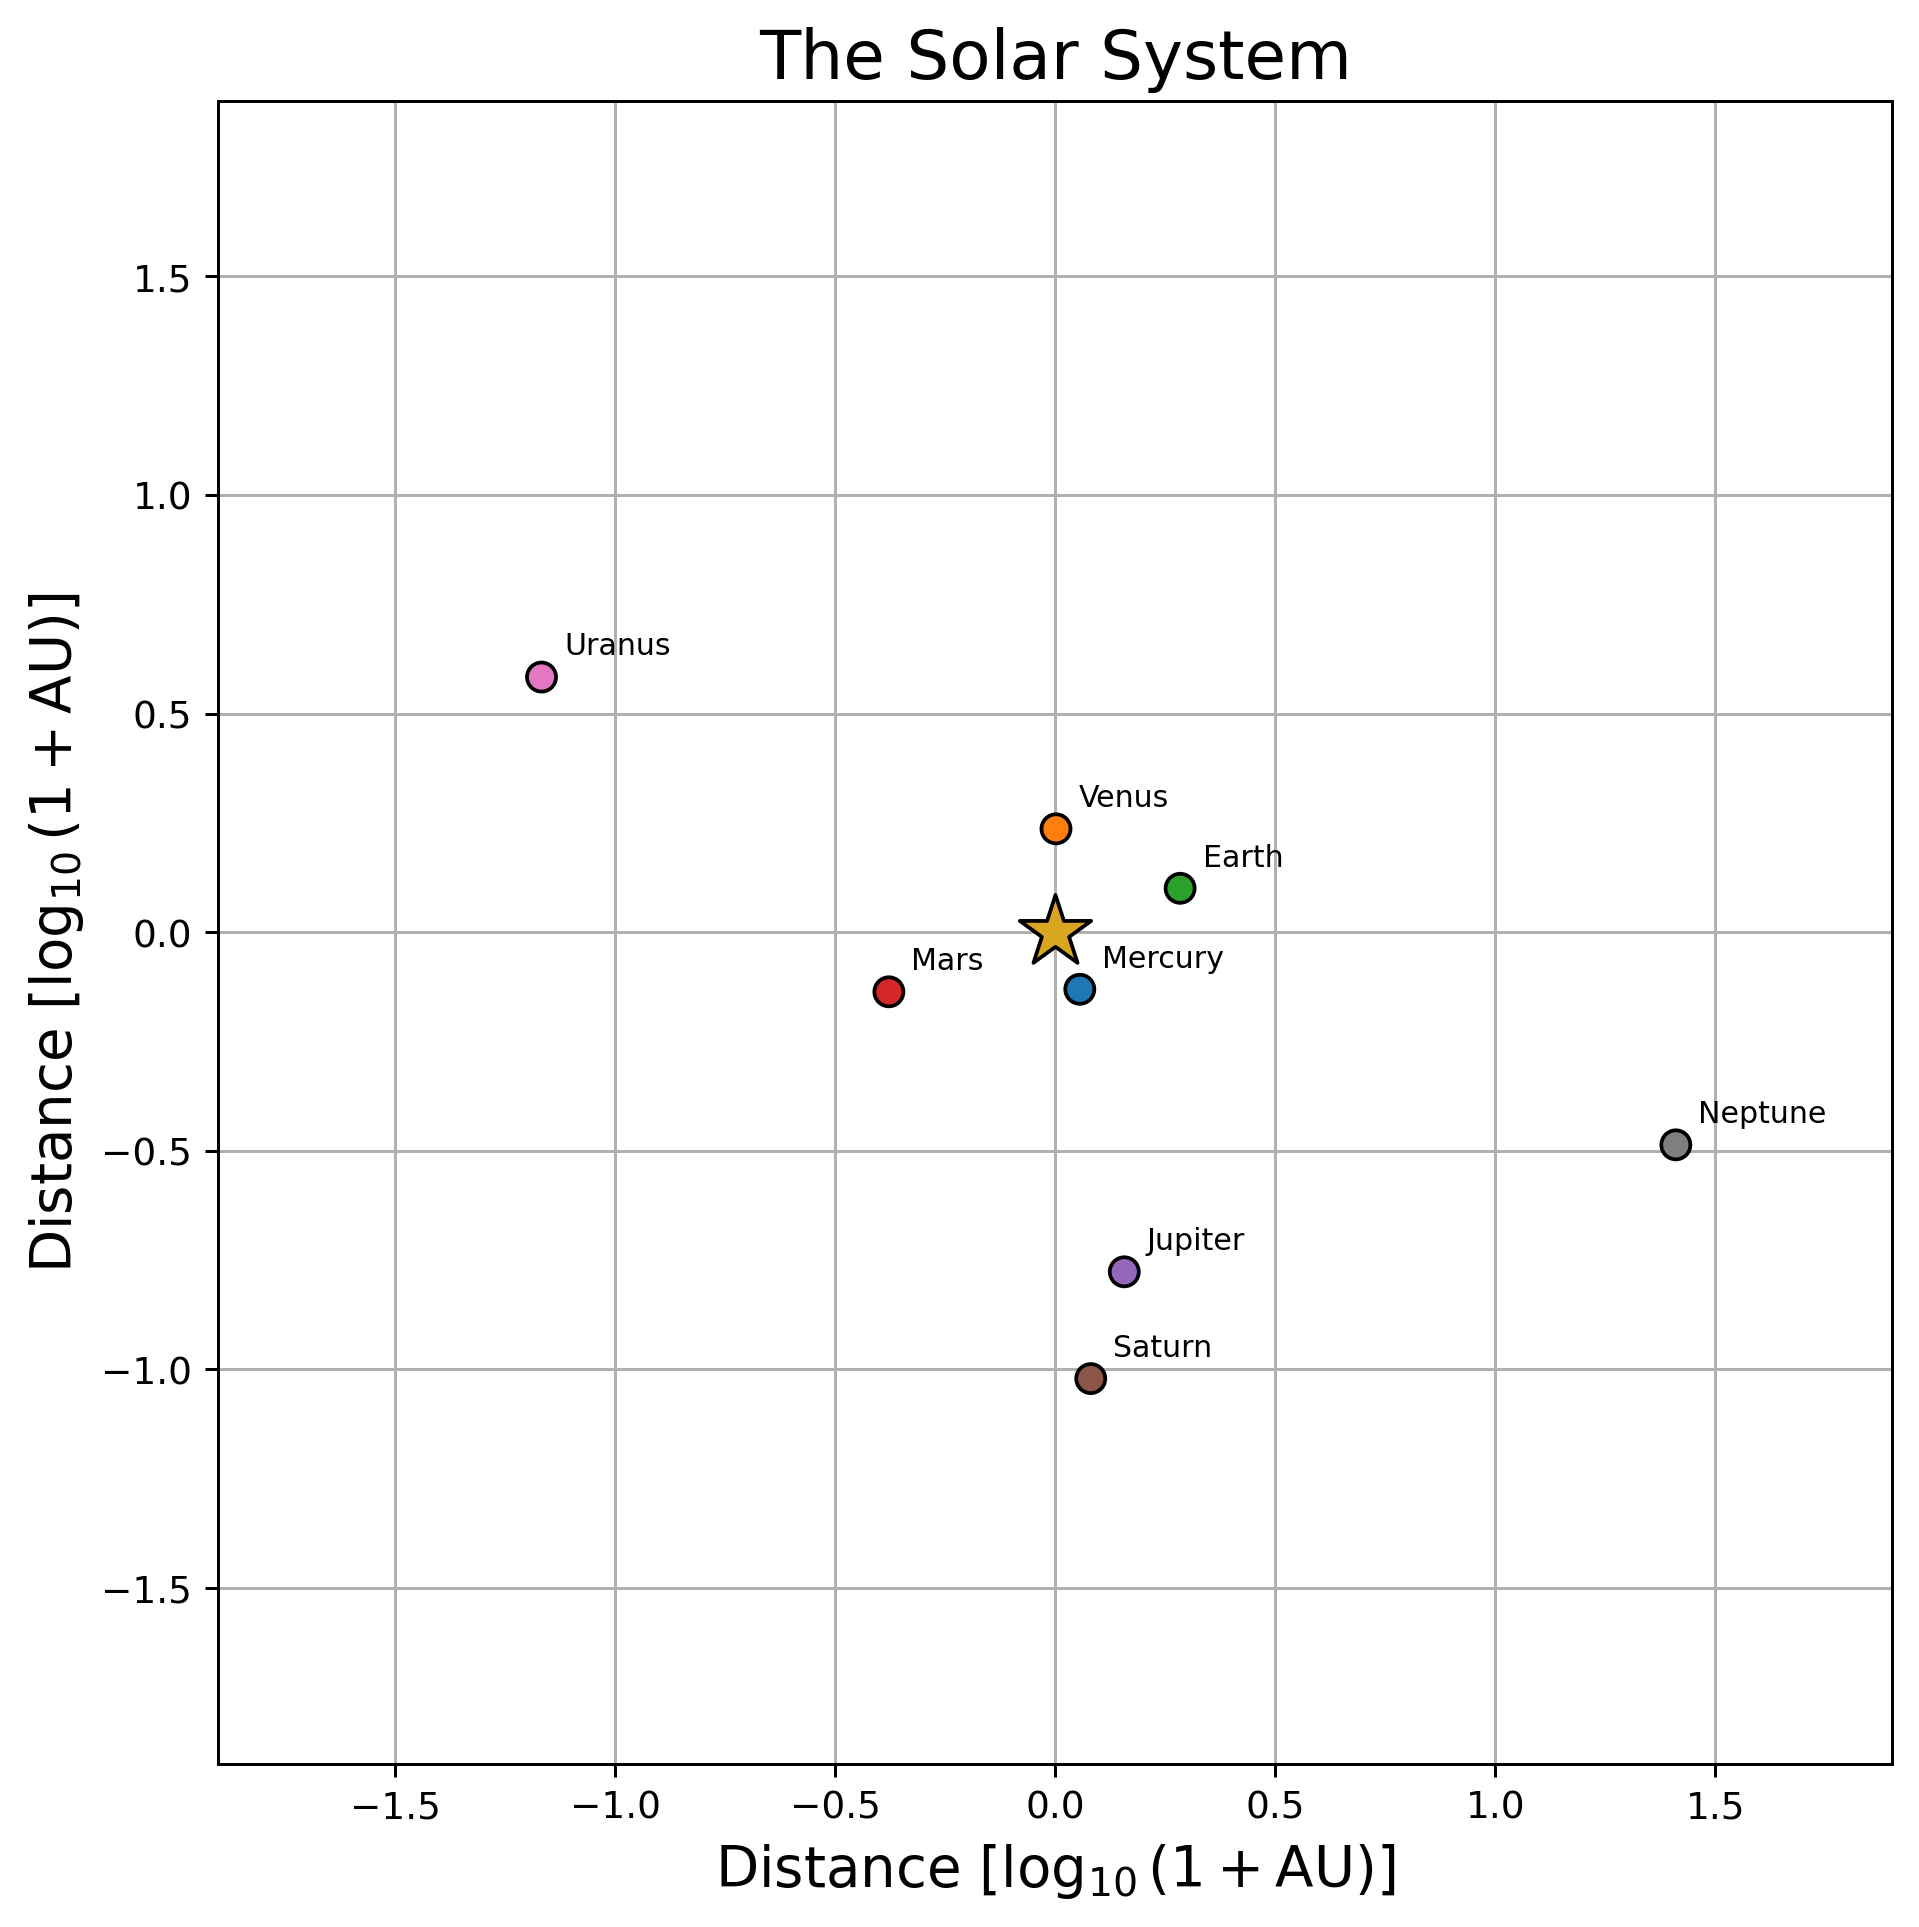

Initial plotting complete in 0 hours; 0 minutes; 0.1953 seconds.


In [7]:
ss = SolarSystem()

start = t.time()
ss.plot(scale_type="log")
end = t.time()

time_printer(st=start, en=end, op="initial plotting")

In [8]:
start = t.time()
x_hist, v_hist, a_hist = ss.integrate(h=DT, N=int(STEPS))
end = t.time()

time_printer(st=start, en=end, op="gravity simulation")

Algorithm has just begun!

Algorithm has run 10% to completion!
Algorithm has run 20% to completion!
Algorithm has run 30% to completion!
Algorithm has run 40% to completion!
Algorithm has run 50% to completion!
Algorithm has run 60% to completion!
Algorithm has run 70% to completion!
Algorithm has run 80% to completion!
Algorithm has run 90% to completion!

Gravity simulation complete in 1 hour; 57 minutes; 16.1991 seconds.


In [ ]:
start = t.time()
ss.save_jpegs(num_frames=N_JULIAN_YRS*1200, x_coords_list=x_hist, v_coords_list=v_hist, a_coords_list=a_hist, scale_type="log")
end = t.time()

time_printer(st=start, en=end, op="saving jpegs")

Algorithm has just begun!

Algorithm has run 10% to completion!


# E.O.F.